In [1]:
import pandas as pd

# Carica il dataset
df = pd.read_csv('train(1).csv')

# Visualizza le prime 5 righe per controllare che sia tutto ok
print(df.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


In [2]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [4]:
df.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

In [5]:
df = df.drop(['PassengerId', 'Name'], axis=1)

In [6]:
df.isna().sum()

HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
dtype: int64

In [7]:
import numpy as np

df[['Deck','CabinNum','Side']] = df['Cabin'].str.split('/', expand=True)
df = df.drop('Cabin', axis=1)

df['Deck'] = df['Deck'].fillna('Unknown')
df['Side'] = df['Side'].fillna('Unknown')
df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')
df['CabinNum'] = df['CabinNum'].fillna(df['CabinNum'].median())

df['HomePlanet'] = df['HomePlanet'].fillna('Unknown')
df['Destination'] = df['Destination'].fillna('Unknown')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['IsChild'] = (df['Age'] < 18).astype(int)

df['VIP'] = df['VIP'].fillna(False).astype(int)

spesa_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
df[spesa_cols] = df[spesa_cols].fillna(0)

df['TotalSpend'] = df[spesa_cols].sum(axis=1)
df['TotalSpend'] = np.log1p(df['TotalSpend'])

df['NoSpend'] = (df['TotalSpend'] == 0).astype(int)
df['NoSpa'] = (df['Spa'] == 0).astype(int)
df['NoFood'] = (df['FoodCourt'] == 0).astype(int)

df['AvgSpend'] = df['TotalSpend'] / (df['Age'] + 1)

df['CryoSleep'] = df['CryoSleep'].fillna(df['NoSpend'] == 1)
df['CryoSleep'] = df['CryoSleep'].astype(int)

df['Route'] = df['HomePlanet'] + "_" + df['Destination']

In [8]:
df.duplicated().sum()

np.int64(24)

In [9]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
df.isna().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
CabinNum        0
Side            0
IsChild         0
TotalSpend      0
NoSpend         0
NoSpa           0
NoFood          0
AvgSpend        0
Route           0
dtype: int64

In [11]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

print(df.dtypes)

HomePlanet      category
CryoSleep          int64
Destination     category
Age              float64
VIP                int64
RoomService      float64
FoodCourt        float64
ShoppingMall     float64
Spa              float64
VRDeck           float64
Transported         bool
Deck            category
CabinNum         float64
Side            category
IsChild            int64
TotalSpend       float64
NoSpend            int64
NoSpa              int64
NoFood             int64
AvgSpend         float64
Route           category
dtype: object


C:\Users\veryv\AppData\Local\Temp\ipykernel_21300\331661104.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


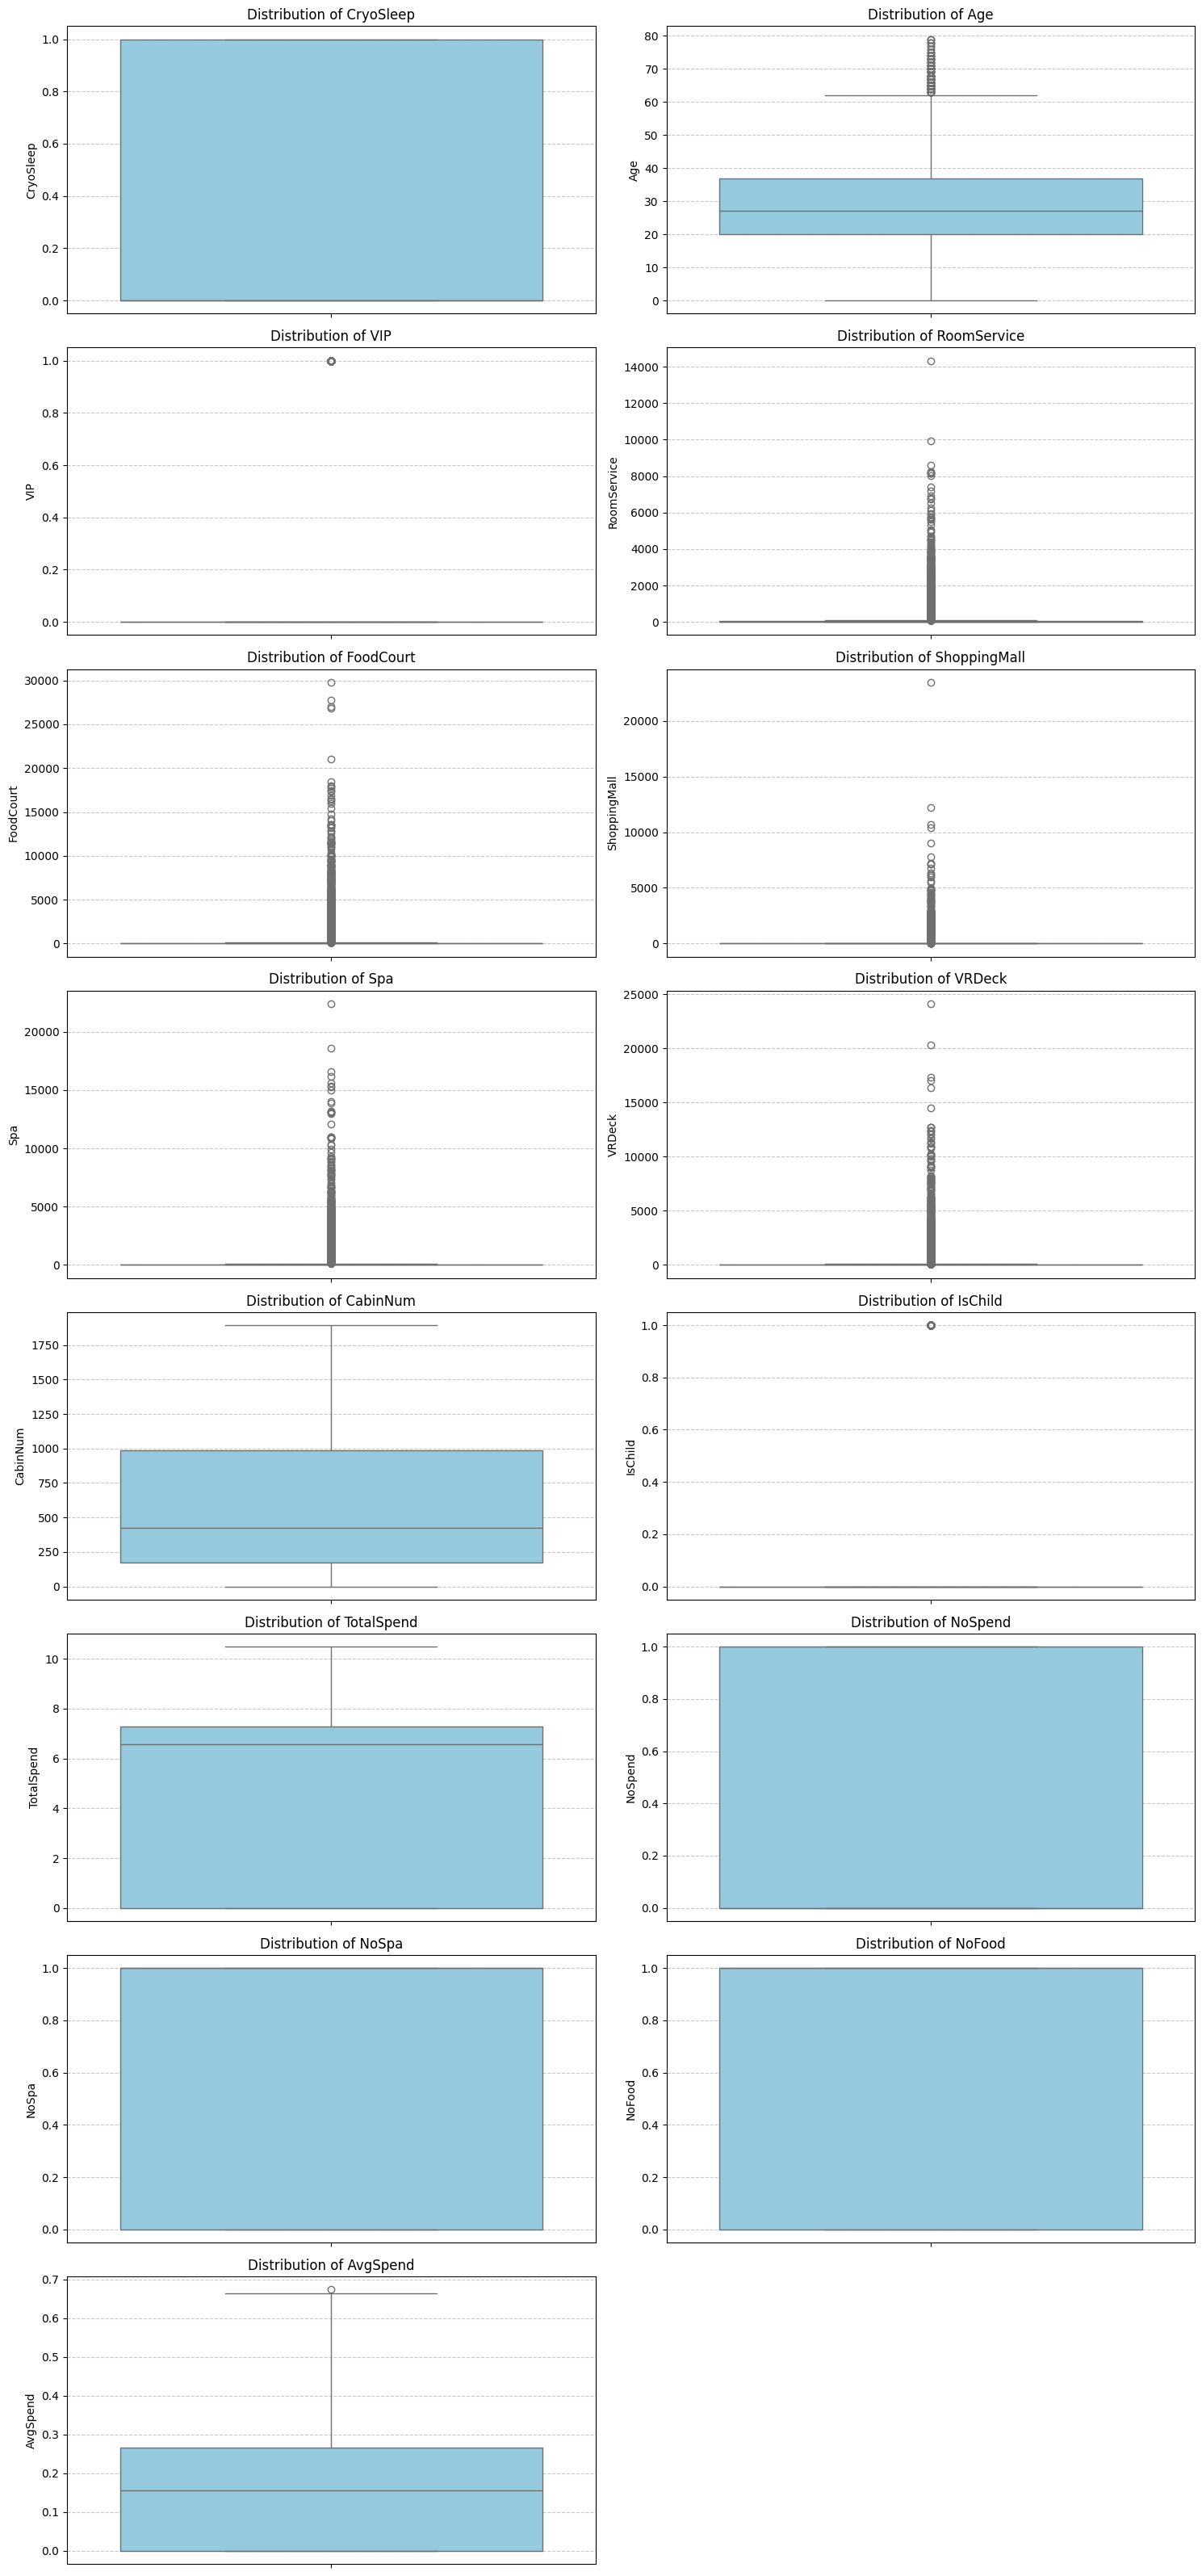

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Setup the grid dimensions (e.g., 3 columns per row)
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)

# 3. Create the figure
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Final adjustments and saving
plt.tight_layout()
plt.savefig('numeric_boxplots.png')

In [13]:
# Isolate the target
y = df['Transported'].astype(int)

# Drop the target from the main DataFrame to create the feature set
X = df.drop(columns=['Transported'])

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (8669, 20)
Target shape: (8669,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

In [22]:
import optuna
from sklearn.metrics import f1_score

ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'n_jobs': -1,
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', ratio*0.8, ratio*1.2),
        'lambda': trial.suggest_float('lambda', 1e-8, 10, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 15),
    }

    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, 'eval-logloss')

    bst = xgb.train(
        param, 
        dtrain, 
        num_boost_round=3000,
        evals=[(dtest, 'eval')],
        callbacks=[pruning_callback],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    preds_prob = bst.predict(dtest)
    preds = [1 if p > 0.5 else 0 for p in preds_prob]

    return f1_score(y_test, preds)

optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest F1-score: {study.best_trial.value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-03-04 17:13:36,071] A new study created in memory with name: no-name-e0bfaf96-98c3-4462-8579-1826833ade2a
  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.791489:   2%|▏         | 1/50 [00:01<00:49,  1.01s/it]

[I 2026-03-04 17:13:37,106] Trial 0 finished with value: 0.7914893617021277 and parameters: {'scale_pos_weight': 0.8278052328248702, 'lambda': 1.4308152717171083e-07, 'alpha': 0.001469298316742619, 'subsample': 0.6508696870281708, 'colsample_bytree': 0.6666987076294522, 'max_depth': 14, 'learning_rate': 0.03969673817988656, 'min_child_weight': 10}. Best is trial 0 with value: 0.7914893617021277.


Best trial: 1. Best value: 0.822058:   4%|▍         | 2/50 [00:02<00:59,  1.24s/it]

[I 2026-03-04 17:13:38,509] Trial 1 finished with value: 0.8220579874928937 and parameters: {'scale_pos_weight': 1.174784629180819, 'lambda': 1.6797545784464953e-08, 'alpha': 0.8437918687748983, 'subsample': 0.776248467787745, 'colsample_bytree': 0.8336609743274095, 'max_depth': 6, 'learning_rate': 0.021619043810312915, 'min_child_weight': 15}. Best is trial 1 with value: 0.8220579874928937.


...

[I 2026-03-04 17:14:51,231] Trial 47 finished with value: 0.8181818181818182 and parameters: {'scale_pos_weight': 1.1870764723656106, 'lambda': 0.0020784460106913366, 'alpha': 0.10328810104514385, 'subsample': 0.6566967445862644, 'colsample_bytree': 0.8447959825126156, 'max_depth': 9, 'learning_rate': 0.03982086263347686, 'min_child_weight': 14}. Best is trial 1 with value: 0.8220579874928937.


Best trial: 1. Best value: 0.822058:  98%|█████████▊| 49/50 [01:15<00:01,  1.04s/it]

[I 2026-03-04 17:14:51,968] Trial 48 finished with value: 0.8147295742232451 and parameters: {'scale_pos_weight': 1.0930298083670043, 'lambda': 0.009667746159294846, 'alpha': 4.208640313851255, 'subsample': 0.7974191047782903, 'colsample_bytree': 0.7422161060512018, 'max_depth': 13, 'learning_rate': 0.05734565309474956, 'min_child_weight': 15}. Best is trial 1 with value: 0.8220579874928937.


Best trial: 1. Best value: 0.822058: 100%|██████████| 50/50 [01:16<00:00,  1.53s/it]

[I 2026-03-04 17:14:52,363] Trial 49 finished with value: 0.8009367681498829 and parameters: {'scale_pos_weight': 1.0027838670226825, 'lambda': 0.05821232938761069, 'alpha': 2.325823064430911, 'subsample': 0.6450111215020617, 'colsample_bytree': 0.7673218842949031, 'max_depth': 11, 'learning_rate': 0.14430574965288342, 'min_child_weight': 12}. Best is trial 1 with value: 0.8220579874928937.

Best F1-score: 0.8221
Best params: {'scale_pos_weight': 1.174784629180819, 'lambda': 1.6797545784464953e-08, 'alpha': 0.8437918687748983, 'subsample': 0.776248467787745, 'colsample_bytree': 0.8336609743274095, 'max_depth': 6, 'learning_rate': 0.021619043810312915, 'min_child_weight': 15}


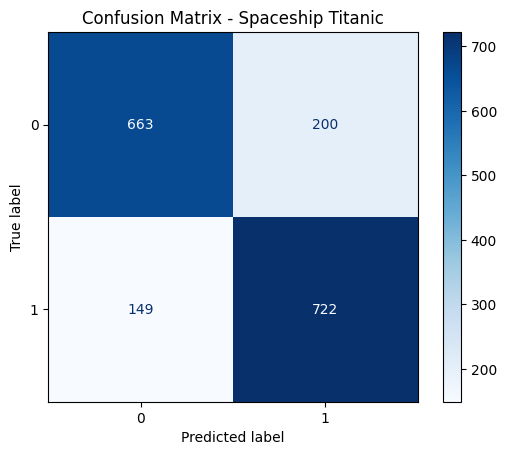

              precision    recall  f1-score   support

           0       0.82      0.77      0.79       863
           1       0.78      0.83      0.81       871

    accuracy                           0.80      1734
   macro avg       0.80      0.80      0.80      1734
weighted avg       0.80      0.80      0.80      1734



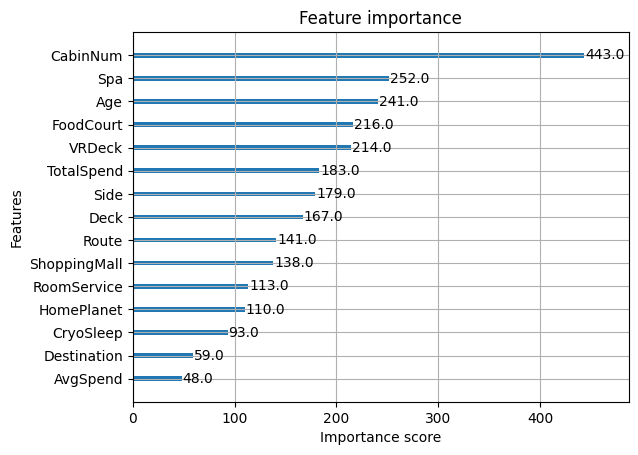

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_params = study.best_params
best_params.update({
    'enable_categorical': True,
    'tree_method': 'hist',
    'objective': 'binary:logistic'
})

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

preds_proba = final_model.predict_proba(X_test)[:,1]
best_thresh = 0.5 # Sperimenta 0.45, 0.55, ecc.

y_pred = (preds_proba > best_thresh).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Spaceship Titanic')
plt.show()

# Classification report
print(classification_report(y_test, y_pred))

xgb.plot_importance(final_model, max_num_features=15)
plt.show()